In [2]:
!pip install ultralytics
!pip install roboflow
!pip install -q ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 146.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


In [27]:
from google.colab import drive
from google.colab import files
from ultralytics import YOLO
from roboflow import Roboflow
import os
import yaml
import time
import shutil
from pathlib import Path
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from PIL import Image
from IPython.display import Image
from IPython.display import display
from datetime import datetime
from ultralytics.utils import callbacks

In [4]:
rf = Roboflow(api_key="KXpW9OEEHMr7U8ESRMBx")
project = rf.workspace("material-identification").project("garbage-classification-3")
version = project.version(2)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to GARBAGE-CLASSIFICATION-3-2 in yolov8:: 100%|██████████| 20940/20940 [00:01<00:00, 11376.90it/s]


In [5]:
DATASET_PATH = dataset.location
print(DATASET_PATH)

/content/GARBAGE-CLASSIFICATION-3-2


In [64]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
PROJECT_NAME = "SmartWaste_YOLOv8s"

SAVE_DIR = f"/content/drive/MyDrive/{PROJECT_NAME}"

REMAPPED_PATH = f"{SAVE_DIR}/dataset_remapped"

DRIVE_SAVE_DIR = f"{SAVE_DIR}/checkpoints"

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

In [8]:
print(dataset.location)
print()

if os.path.exists(dataset.location):
    for item in os.listdir(dataset.location):
        print(item)
else:
    print(f"Error: Directory '{dataset.location}' not found.")
    print("Please re-run the Roboflow dataset download cell (MOnWYIeFhlLn) to ensure the dataset is extracted.")

/content/GARBAGE-CLASSIFICATION-3-2

test
train
valid
README.roboflow.txt
README.dataset.txt
data.yaml


In [28]:
yaml_path = f"{DATASET_PATH}/data.yaml"

with open(yaml_path) as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml["names"])

mapping = {
    0: 3,  # BIODEGRADABLE -> Organic
    1: 1,  # CARDBOARD -> Paper
    2: 0,  # Glass
    3: 2,  # Metal
    4: 1,  # PAPER -> Paper
    5: 4   # Plastic
}

for split in ["train", "valid", "test"]:

    img_src = f"{DATASET_PATH}/{split}/images"
    lbl_src = f"{DATASET_PATH}/{split}/labels"

    img_dst = f"{REMAPPED_PATH}/{split}/images"
    lbl_dst = f"{REMAPPED_PATH}/{split}/labels"

    os.makedirs(img_dst, exist_ok=True)
    os.makedirs(lbl_dst, exist_ok=True)

    for img in os.listdir(img_src):
        shutil.copy2(
            os.path.join(img_src, img),
            os.path.join(img_dst, img)
        )

    for txt in os.listdir(lbl_src):

        src_txt = os.path.join(lbl_src, txt)
        dst_txt = os.path.join(lbl_dst, txt)

        new_lines = []

        with open(src_txt) as f:
            lines = f.readlines()

        for line in lines:

            parts = line.strip().split()

            if len(parts) < 5:
                continue

            old_class = int(parts[0])

            parts[0] = str(mapping[old_class])

            new_lines.append(" ".join(parts))

        with open(dst_txt, "w") as f:
            f.write("\n".join(new_lines))

print("Remap selesai.")

['BIODEGRADABLE', 'CARDBOARD', 'GLASS', 'METAL', 'PAPER', 'PLASTIC']
Remap selesai.


In [40]:
new_yaml = {
    "train": f"{REMAPPED_PATH}/train/images",
    "val": f"{REMAPPED_PATH}/valid/images",
    "test": f"{REMAPPED_PATH}/test/images",
    "nc": 5,
    "names": [
        "Kaca",
        "Kertas",
        "Logam",
        "Organik",
        "Plastik"
    ]
}
new_yaml_path = f"{REMAPPED_PATH}/data.yaml"
with open(new_yaml_path, "w") as f:
    yaml.dump(new_yaml, f)
print(new_yaml_path)

/content/drive/MyDrive/SmartWaste_YOLOv8s/dataset_remapped/data.yaml


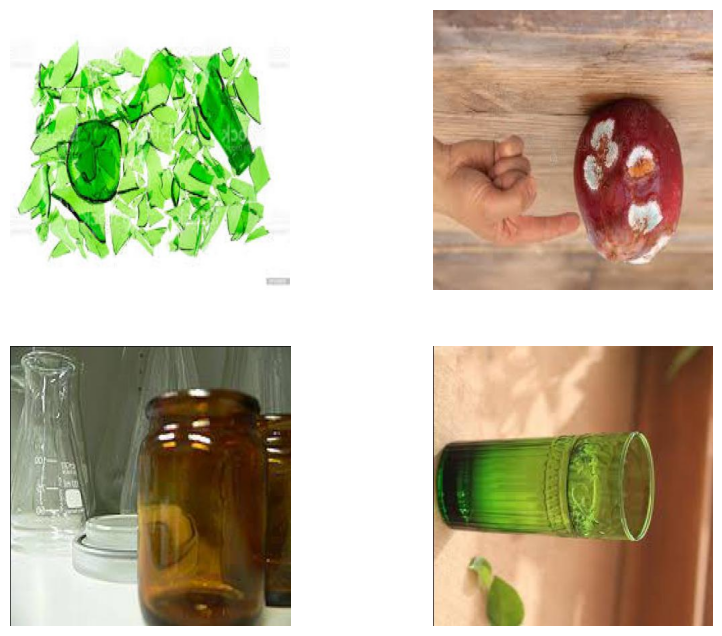

In [54]:
from PIL import Image as PIL_Image # Import PIL.Image with an alias

img_dir = f"{dataset.location}/train/images"

samples = random.sample(
    os.listdir(img_dir),
    4
)

plt.figure(figsize=(10,8))

for i,img in enumerate(samples):

    plt.subplot(2,2,i+1)

    image = PIL_Image.open( # Use the alias here
        os.path.join(img_dir,img)
    )

    plt.imshow(image)

    plt.axis("off")

plt.show()

In [42]:
AUTOSAVE_EVERY_N_EPOCH = 10

def on_train_epoch_end(trainer):
    """Callback: simpan checkpoint ke Drive setiap N epoch."""
    epoch = trainer.epoch + 1
    if epoch % AUTOSAVE_EVERY_N_EPOCH == 0:
        timestamp = datetime.now().strftime("%H%M")
        dest_name = f"checkpoint_epoch{epoch:03d}_{timestamp}.pt"
        dest_path = os.path.join(DRIVE_SAVE_DIR, dest_name)

        last_pt = os.path.join(trainer.save_dir, "weights", "last.pt")
        if os.path.exists(last_pt):
            shutil.copy(last_pt, dest_path)
            print(f"\n💾 [Epoch {epoch}] Auto-save → {dest_name}")
        else:
            print(f"\n⚠️  [Epoch {epoch}] last.pt belum ada, lewati auto-save.")

def on_train_end(trainer):
    """Callback: simpan best.pt dan grafik hasil ke Drive saat training selesai."""
    print("\n🏁 Training selesai! Menyimpan hasil ke Google Drive...")

    save_dir = trainer.save_dir
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")

    best_pt = os.path.join(save_dir, "weights", "best.pt")
    if os.path.exists(best_pt):
        dest = os.path.join(DRIVE_SAVE_DIR, f"best_{timestamp}.pt")
        shutil.copy(best_pt, dest)
        print(f"   ✅ best.pt  → {dest}")

    last_pt = os.path.join(save_dir, "weights", "last.pt")
    if os.path.exists(last_pt):
        dest = os.path.join(DRIVE_SAVE_DIR, f"last_{timestamp}.pt")
        shutil.copy(last_pt, dest)
        print(f"   ✅ last.pt  → {dest}")

    results_csv = os.path.join(save_dir, "results.csv")
    if os.path.exists(results_csv):
        dest = os.path.join(DRIVE_SAVE_DIR, f"results_{timestamp}.csv")
        shutil.copy(results_csv, dest)
        print(f"   ✅ results.csv → {dest}")

    for fname in ["confusion_matrix.png", "confusion_matrix_normalized.png", "results.png"]:
        fpath = os.path.join(save_dir, fname)
        if os.path.exists(fpath):
            dest = os.path.join(DRIVE_SAVE_DIR, f"{fname.replace('.', f'_{timestamp}.')}")
            shutil.copy(fpath, dest)
            print(f"   ✅ {fname} → disimpan")

    print(f"\n📁 Semua file tersimpan di Drive: SmartWaste_DatasetYoloV8/hasil_training/")

print(" Callback auto-save berhasil didefinisikan.")
print(f"   Auto-save interval : setiap {AUTOSAVE_EVERY_N_EPOCH} epoch")
print(f"   Folder tujuan Drive: {DRIVE_SAVE_DIR}")

 Callback auto-save berhasil didefinisikan.
   Auto-save interval : setiap 10 epoch
   Folder tujuan Drive: /content/drive/MyDrive/SmartWaste_YOLOv8s/checkpoints


In [43]:
model = YOLO("yolov8s.pt")
model.add_callback(
    "on_train_epoch_end",
    on_train_epoch_end
)

model.add_callback(
    "on_train_end",
    on_train_end
)

results = model.train(
    data=new_yaml_path,
    epochs=100,
    patience=None,
    imgsz=640,
    batch=64,
    optimizer="AdamW",
    lr0=0.001,
    workers=2,
    save=True,
    save_period=5,
    project=SAVE_DIR,
    name="yolov8s_5class",
    plots=True,
    verbose=True,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    device=0
)

print("Training selesai!")

New https://pypi.org/project/ultralytics/8.4.73 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/SmartWaste_YOLOv8s/dataset_remapped/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, m

In [56]:
metrics = model.val()

print("📊 Hasil Evaluasi:")
print(f"   mAP50-95 (semua kelas): {round(metrics.box.map, 4)}")
print(f"   mAP50    (semua kelas): {round(metrics.box.map50, 4)}")

print("\n   mAP50 per kelas:")
for i, class_name in enumerate(new_yaml):
    score = metrics.box.maps[i]
    bar = '█' * int(score * 20)
    print(f"   {class_name:8s}: {score:.3f}  {bar}")

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 8.6±6.3 MB/s, size: 17.7 KB)
val: Scanning /content/drive/MyDrive/SmartWaste_YOLOv8s/dataset_remapped/valid/labels.cache... 2098 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2098/2098 628.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 132/132 5.2it/s 25.5s
                   all       2098      18916      0.742      0.557      0.639      0.433
                  Kaca        805       2380      0.878      0.696      0.809      0.591
                Kertas        449       1325      0.743      0.514      0.613      0.456
                 Logam        398       1360      0.781      0.629      0.716      0.472
               Organik        676      13637      0.829      0.486      0.632      0.355
               Plastik         91        214      0.482      0.458      

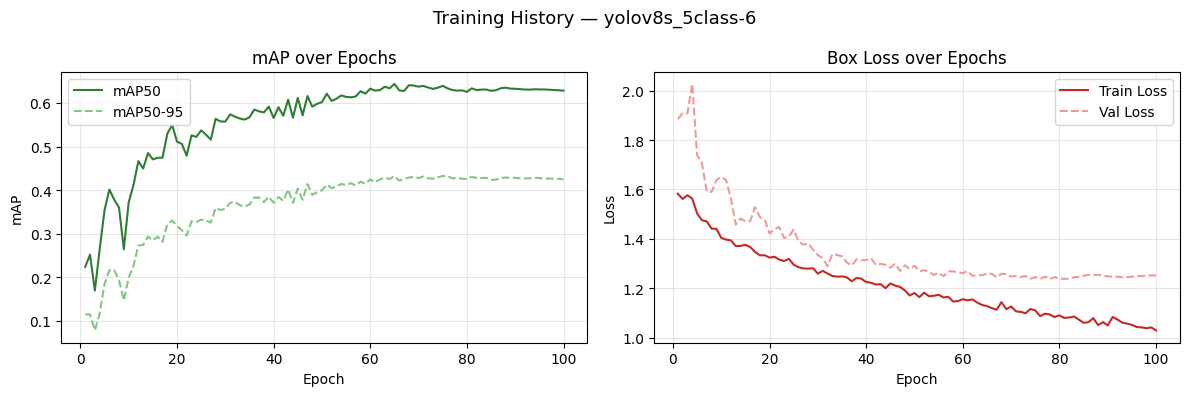

✅ Grafik disimpan ke Drive: training_history_20260621_1847.png


In [50]:
results_csv = os.path.join(results.save_dir, "results.csv")

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df["epoch"], df["metrics/mAP50(B)"], color="#2e7d32", label="mAP50")
axes[0].plot(df["epoch"], df["metrics/mAP50-95(B)"], color="#81c784", linestyle="--", label="mAP50-95")
axes[0].set_title("mAP over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("mAP")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["epoch"], df["train/box_loss"], color="#c62828", label="Train Loss")
axes[1].plot(df["epoch"], df["val/box_loss"], color="#ef9a9a", linestyle="--", label="Val Loss")
axes[1].set_title("Box Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

run_name = os.path.basename(results.save_dir)
plt.suptitle(f"Training History — {run_name}", fontsize=13)
plt.tight_layout()

local_graph = "yolo_training_history.png"
plt.savefig(local_graph, dpi=150, bbox_inches="tight")
plt.show()

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
drive_graph = os.path.join(DRIVE_SAVE_DIR, f"training_history_{timestamp}.png")
shutil.copy(local_graph, drive_graph)
print(f"✅ Grafik disimpan ke Drive: training_history_{timestamp}.png")

In [77]:
!find \"/content/drive/MyDrive\" -name \"*.pt\

find: ‘"/content/drive/MyDrive"’: No such file or directory
